Loaded shape: (50000, 5)
Sample before:
 one other reviewers has mentioned that after watching just 1 oz episode you ll be hooked they are right as this exactly what happened with me first thing that struck me about oz was its brutality unfl...
Sample after:
 one other review ha mention that after watch just 1 oz episod you ll be hook they are right as thi exactli what happen with me first thing that struck me about oz wa it brutal unflinch scene violenc w...


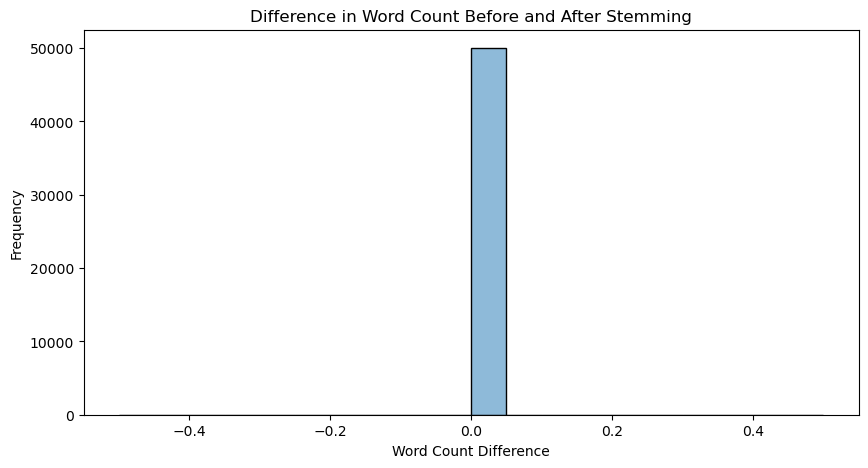

Saved to: stemmed.csv


In [2]:
# IT24100163_Stemming.ipynb
# IT24100163 - Stemming
# Justification: Words with the same root (e.g., 'running', 'runs') should contribute similarly to sentiment. Stemming reduces redundancy for efficient feature representation.
# Technique: Apply Porter Stemmer to reduce words to their root form.

# Import libraries
import pandas as pd
from nltk.stem import PorterStemmer
import nltk
import matplotlib.pyplot as plt  # Added import for matplotlib
import seaborn as sns  # Added import for seaborn

# Load data from previous step
df = pd.read_csv('../results/outputs/stopwords_removed.csv')
print("Loaded shape:", df.shape)
df.head()

# Apply stemming
stemmer = PorterStemmer()
df['review'] = df['review'].apply(lambda x: ' '.join(stemmer.stem(word) for word in x.split()))

# EDA: Print sample comparison
print("Sample before:\n", pd.read_csv('../results/outputs/stopwords_removed.csv')['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# Additional EDA Visualization: Word count difference histogram
df['word_count_before'] = pd.read_csv('../results/outputs/stopwords_removed.csv')['review'].apply(lambda x: len(x.split()))
df['word_count_after'] = df['review'].apply(lambda x: len(x.split()))
df['diff'] = df['word_count_before'] - df['word_count_after']

plt.figure(figsize=(10, 5))
sns.histplot(df['diff'], bins=20, kde=True)
plt.title("Difference in Word Count Before and After Stemming")
plt.xlabel("Word Count Difference")
plt.ylabel("Frequency")
plt.show()

# Interpretation: Sample shows word reductions (e.g., 'watching' to 'watch'); histogram typically shows small negative differences (0 to -5) as stemming consolidates variants.

# Save processed data
df.to_csv('../results/outputs/stemmed.csv', index=False)
print("Saved to: stemmed.csv")